# CompScale Sanity — Module 1 + 6 quick-look

Aggregates every `sanity_results*.json` in `compscale/evaluation/results/`,
then checks:

- **Module 1 baseline gate** — per-type per-constraint satisfaction at k=1 must be ≥ 0.5.
- **Module 6 independence gate** — at k=8, observed all-satisfied rate should fall
  below the independence prediction `p^k` (where `p` is the k=1 per-constraint rate),
  with the upper 95% bootstrap CI bound also below 1.0.

Right now only `sanity_results.json` (attribute, 1200 constraints) has landed.
Re-run cell 2 once the Linux server drops the other three pilots.

In [ ]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path("compscale/evaluation/results")
RESULT_FILES = sorted(RESULTS_DIR.glob("sanity_results*.json"))
print("Found result files:")
for f in RESULT_FILES:
    print(f"  {f}")

Found result files:
  compscale\evaluation\results\sanity_results.json
  compscale\evaluation\results\sanity_results_neg_spat_num.json


In [ ]:
# Flatten all result files into two DataFrames:
#   records_df: one row per (prompt_id, image_index) with k, type, all_satisfied, satisfaction_rate
#   constraints_df: one row per (prompt_id, image_index, constraint_idx) with satisfied bool

records, constraints = [], []
for path in RESULT_FILES:
    items = json.loads(path.read_text())
    for r in items:
        records.append({
            "source": path.name,
            "prompt_id": r["prompt_id"],
            "type": r["type"],
            "k": r["k"],
            "image_index": r["image_index"],
            "satisfaction_rate": r["satisfaction_rate"],
            "all_satisfied": r["all_satisfied"],
        })
        for i, c in enumerate(r["constraints"]):
            constraints.append({
                "source": path.name,
                "prompt_id": r["prompt_id"],
                "type": r["type"],
                "k": r["k"],
                "image_index": r["image_index"],
                "constraint_idx": i,
                "satisfied": bool(c["satisfied"]),
                "vlm_batched": c.get("vlm_batched", False),
            })

records_df = pd.DataFrame(records)
constraints_df = pd.DataFrame(constraints)
print(f"records    : {len(records_df)} rows")
print(f"constraints: {len(constraints_df)} rows")
print(f"types      : {sorted(records_df['type'].unique())}")
print(f"k levels   : {sorted(records_df['k'].unique())}")
print(f"batched    : {constraints_df['vlm_batched'].sum()}/{len(constraints_df)} "
      f"constraints evaluated via batched VLM call")

records    : 800 rows
constraints: 3000 rows
types      : ['attribute', 'negation', 'numeracy', 'spatial']
k levels   : [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]
batched    : 1800/3000 constraints evaluated via batched VLM call


## Coverage: prompts per (type, k)

Sanity-check that every (type, k) cell has 20 unique prompts for attribute and 10
for the other three (from `generate_prompts.py`), and 4 images per prompt.

In [ ]:
coverage = (records_df
            .groupby(["type", "k"])
            .agg(n_images=("prompt_id", "size"),
                 n_prompts=("prompt_id", "nunique"))
            .reset_index())
coverage["imgs_per_prompt"] = coverage["n_images"] / coverage["n_prompts"]
coverage

,type,k,n_images,n_prompts,imgs_per_prompt
0,attribute,1,80,20,4.0
1,attribute,2,80,20,4.0
2,attribute,4,80,20,4.0
3,attribute,8,80,20,4.0
4,negation,1,40,10,4.0
5,negation,2,40,10,4.0
6,negation,4,40,10,4.0
7,negation,8,40,10,4.0
8,numeracy,1,40,10,4.0
9,numeracy,2,40,10,4.0


## Module 1 baseline gate

Per-constraint satisfaction at k=1. Need **p ≥ 0.5** for the type to qualify
for scaling-law fitting on this model. Pilot v3 on klein 4B gave attribute
p=0.975 and numeracy p≈0.35 — we expect klein 9B attribute p to be ≥ 0.97.

In [ ]:
def wilson_ci(k_successes, n_trials, z=1.96):
    if n_trials == 0:
        return (float("nan"), float("nan"))
    p = k_successes / n_trials
    denom = 1 + z**2 / n_trials
    center = (p + z**2 / (2 * n_trials)) / denom
    halfw = z * np.sqrt(p * (1 - p) / n_trials + z**2 / (4 * n_trials**2)) / denom
    return (center - halfw, center + halfw)


baseline_rows = []
for (t, k), grp in constraints_df.groupby(["type", "k"]):
    n, s = len(grp), int(grp["satisfied"].sum())
    lo, hi = wilson_ci(s, n)
    baseline_rows.append({
        "type": t, "k": k,
        "n_constraints": n,
        "per_constraint_sat": s / n,
        "ci_lo": lo, "ci_hi": hi,
    })
baseline_df = pd.DataFrame(baseline_rows).sort_values(["type", "k"])

gate_k1 = (baseline_df[baseline_df["k"] == 1]
           .assign(pass_module_1=lambda d: d["per_constraint_sat"] >= 0.5))
print("Module 1 gate (p >= 0.5 at k=1):")
print(gate_k1[["type", "per_constraint_sat", "ci_lo", "ci_hi", "pass_module_1"]]
      .to_string(index=False))
baseline_df

Module 1 gate (p >= 0.5 at k=1):
     type  per_constraint_sat    ci_lo    ci_hi  pass_module_1
attribute               1.000 0.954180 1.000000           True
 negation               0.675 0.520175 0.799157           True
 numeracy               0.775 0.624966 0.876840           True
  spatial               0.425 0.285092 0.578052          False


,type,k,n_constraints,per_constraint_sat,ci_lo,ci_hi
0,attribute,1,80,1.000000,0.954180,1.000000
1,attribute,2,160,0.987500,0.955574,0.996565
2,attribute,4,320,0.978125,0.955542,0.989364
3,attribute,8,640,0.965625,0.948502,0.977192
4,negation,1,40,0.675000,0.520175,0.799157
5,negation,2,80,0.912500,0.830230,0.956969
6,negation,4,160,0.462500,0.387028,0.539731
7,negation,8,320,0.593750,0.539134,0.646141
8,numeracy,1,40,0.775000,0.624966,0.876840
9,numeracy,2,80,0.700000,0.592316,0.789356


## Per-k scaling table

Per-constraint satisfaction vs. all-satisfied rate by (type, k). All-satisfied
is what the scaling-law fit actually consumes.

In [ ]:
per_k = (records_df
         .groupby(["type", "k"])
         .agg(n_images=("all_satisfied", "size"),
              per_constraint_sat=("satisfaction_rate", "mean"),
              all_satisfied_rate=("all_satisfied", "mean"))
         .reset_index())
per_k

,type,k,n_images,per_constraint_sat,all_satisfied_rate
0,attribute,1,80,1.000000,1.0000
1,attribute,2,80,0.987500,0.9750
2,attribute,4,80,0.978125,0.9125
3,attribute,8,80,0.965625,0.7375
4,negation,1,40,0.675000,0.6750
5,negation,2,40,0.912500,0.8250
6,negation,4,40,0.462500,0.0500
7,negation,8,40,0.593750,0.0000
8,numeracy,1,40,0.775000,0.7750
9,numeracy,2,40,0.700000,0.5250


## Module 6 independence check

Under independent constraint failure, `P(all satisfied at k) = p^k` where `p`
is per-constraint satisfaction at k=1. If observed falls **below** that curve,
constraints are interfering (this is the central finding we're hunting).

Gate: at k=8, `observed / predicted < 1` with **upper 95% bootstrap CI bound < 1**.
Pilot v3 on klein 4B attribute hit ratio 0.84 at k=8.

In [ ]:
RNG = np.random.default_rng(42)
N_BOOT = 5000


def bootstrap_ratio(all_sat_observations, p_k1, k, n_boot=N_BOOT, rng=RNG):
    """Bootstrap 95% CI for observed_all_satisfied / p_k1**k."""
    arr = np.asarray(all_sat_observations, dtype=float)
    if len(arr) == 0 or p_k1 <= 0:
        return (float("nan"), float("nan"), float("nan"))
    obs = arr.mean()
    predicted = p_k1 ** k
    idx = rng.integers(0, len(arr), size=(n_boot, len(arr)))
    boot_means = arr[idx].mean(axis=1)
    boot_ratios = boot_means / predicted
    return obs / predicted, float(np.percentile(boot_ratios, 2.5)), float(np.percentile(boot_ratios, 97.5))


rows = []
for t in sorted(records_df["type"].unique()):
    sub = records_df[records_df["type"] == t]
    p_k1 = sub[sub["k"] == 1]["satisfaction_rate"].mean()
    for k in sorted(sub["k"].unique()):
        obs = sub[sub["k"] == k]["all_satisfied"].values
        predicted = p_k1 ** k
        ratio, ci_lo, ci_hi = bootstrap_ratio(obs, p_k1, k)
        rows.append({
            "type": t, "k": k,
            "p_k1": p_k1,
            "predicted_all_sat": predicted,
            "observed_all_sat": obs.mean() if len(obs) else float("nan"),
            "ratio": ratio,
            "ci_lo": ci_lo, "ci_hi": ci_hi,
        })

indep_df = pd.DataFrame(rows)
indep_df

,type,k,p_k1,predicted_all_sat,observed_all_sat,ratio,ci_lo,ci_hi
0,attribute,1,1.000,1.000000,1.0000,1.000000,1.000000,1.000000
1,attribute,2,1.000,1.000000,0.9750,0.975000,0.937500,1.000000
2,attribute,4,1.000,1.000000,0.9125,0.912500,0.850000,0.962812
3,attribute,8,1.000,1.000000,0.7375,0.737500,0.637500,0.825312
4,negation,1,0.675,0.675000,0.6750,1.000000,0.777778,1.222222
5,negation,2,0.675,0.455625,0.8250,1.810700,1.536351,2.030178
6,negation,4,0.675,0.207594,0.0500,0.240855,0.000000,0.602136
7,negation,8,0.675,0.043095,0.0000,0.000000,0.000000,0.000000
8,numeracy,1,0.775,0.775000,0.7750,1.000000,0.838710,1.161290
9,numeracy,2,0.775,0.600625,0.5250,0.874089,0.624350,1.123829


In [ ]:
gate_k8 = (indep_df[indep_df["k"] == 8]
           .assign(pass_module_6=lambda d: (d["ratio"] < 1.0) & (d["ci_hi"] < 1.0)))
print("Module 6 gate (k=8 ratio < 1 and 95% CI upper bound < 1):")
cols = ["type", "p_k1", "predicted_all_sat", "observed_all_sat",
        "ratio", "ci_lo", "ci_hi", "pass_module_6"]
print(gate_k8[cols].to_string(index=False))

Module 6 gate (k=8 ratio < 1 and 95% CI upper bound < 1):
     type  p_k1  predicted_all_sat  observed_all_sat  ratio  ci_lo    ci_hi  pass_module_6
attribute 1.000           1.000000            0.7375 0.7375 0.6375 0.825312           True
 negation 0.675           0.043095            0.0000 0.0000 0.0000 0.000000           True
 numeracy 0.775           0.130141            0.0000 0.0000 0.0000 0.000000           True
  spatial 0.425           0.001064            0.0000 0.0000 0.0000 0.000000           True


## Plot: observed vs. independence prediction

One curve per type: solid = observed all-satisfied, dashed = p^k independence.
Any gap where solid < dashed is the interference signal.

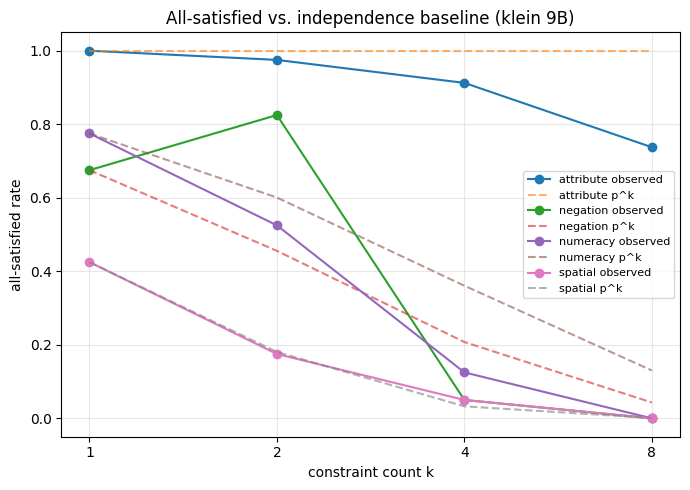

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))
for t, grp in indep_df.groupby("type"):
    grp = grp.sort_values("k")
    ax.plot(grp["k"], grp["observed_all_sat"], marker="o", label=f"{t} observed")
    ax.plot(grp["k"], grp["predicted_all_sat"], linestyle="--", alpha=0.6,
            label=f"{t} p^k")
ax.set_xlabel("constraint count k")
ax.set_ylabel("all-satisfied rate")
ax.set_title("All-satisfied vs. independence baseline (klein 9B)")
ax.set_xscale("log", base=2)
ax.set_xticks(sorted(indep_df["k"].unique()))
ax.set_xticklabels(sorted(indep_df["k"].unique()))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Decay-function fit (attribute only right now)

Fits exponential / sigmoid / power law to `per-constraint satisfaction vs k`
and picks the lowest-AIC form. This is a preview of what
`fit_scaling_law.py` will emit when you run it from the CLI.

In [ ]:
from scipy.optimize import curve_fit

def exp_decay(k, s0, a):       return s0 * np.exp(-a * k)
def sigmoid_decay(k, b, k0):   return 1.0 / (1.0 + np.exp(b * (k - k0)))
def power_decay(k, s0, g):     return s0 * k ** (-g)

def aic(n, residuals, n_params):
    rss = float(np.sum(residuals ** 2))
    if rss <= 0:
        return -np.inf
    return n * np.log(rss / n) + 2 * n_params

fit_rows = []
for t, grp in per_k.groupby("type"):
    grp = grp.sort_values("k")
    x = grp["k"].values.astype(float)
    y = grp["per_constraint_sat"].values.astype(float)
    if len(x) < 3:
        continue
    fits = {}
    for name, fn, p0 in [
        ("exp",     exp_decay,     [y[0], 0.05]),
        ("sigmoid", sigmoid_decay, [0.5, 12]),
        ("power",   power_decay,   [y[0], 0.2]),
    ]:
        try:
            popt, _ = curve_fit(fn, x, y, p0=p0, maxfev=10000)
            pred = fn(x, *popt)
            ss_res = float(np.sum((y - pred) ** 2))
            ss_tot = float(np.sum((y - y.mean()) ** 2))
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
            fits[name] = {
                "params": [float(p) for p in popt],
                "aic": aic(len(x), y - pred, len(popt)),
                "r2": r2,
            }
        except Exception as e:
            fits[name] = {"error": str(e)}
    best = min((n for n in fits if "aic" in fits[n]),
               key=lambda n: fits[n]["aic"], default=None)
    fit_rows.append({"type": t, "best": best, **{f"{n}_{k}": v
                     for n, f in fits.items() for k, v in f.items()}})

fit_df = pd.DataFrame(fit_rows)
fit_df

C:\Users\Soham\AppData\Local\Temp\ipykernel_73148\635506904.py:4: RuntimeWarning: overflow encountered in exp
  def sigmoid_decay(k, b, k0):   return 1.0 / (1.0 + np.exp(b * (k - k0)))
C:\Users\Soham\AppData\Local\Temp\ipykernel_73148\635506904.py:27: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(fn, x, y, p0=p0, maxfev=10000)


,type,best,exp_params,exp_aic,exp_r2,sigmoid_params,sigmoid_aic,sigmoid_r2,power_params,power_aic,power_r2
0,attribute,power,"[0.9999065289438758, 0.004618683786472592]",-41.282697,0.923627,"[0.20840126472350567, 23.82524015889168]",-37.821944,0.818579,"[0.9997511127894855, 0.016513939750598]",-54.097551,0.996898
1,negation,exp,"[0.7831588272562394, 0.047450823154344214]",-11.503362,0.227482,"[0.1192991609236362, 9.429173616311823]",-11.391831,0.205639,"[0.7643674650203227, 0.1456870480930959]",-11.443780,0.215889
2,numeracy,exp,"[0.8232085599323721, 0.07500421434110476]",-33.322916,0.993654,"[0.18453284191286046, 6.842522234819264]",-26.652440,0.966371,"[0.7944921514145263, 0.23275754852969496]",-25.554236,0.955747
3,spatial,power,"[0.3928043614306171, -0.01631017568486766]",-18.880240,0.097707,"[-9.054879607185915, 80.12879330182001]",-2.896422,-48.064652,"[0.39124888021933635, -0.0623994174052487]",-18.938639,0.110784


## Gate summary

Single-screen pass/fail table for Module 1 and Module 6 across available types.
This is the shape of the final `sanity_report.json`.

In [ ]:
summary = (gate_k1[["type", "per_constraint_sat", "pass_module_1"]]
           .rename(columns={"per_constraint_sat": "p_k1"})
           .merge(gate_k8[["type", "ratio", "ci_hi", "pass_module_6"]],
                  on="type", how="outer"))
print(summary.to_string(index=False))

     type  p_k1  pass_module_1  ratio    ci_hi  pass_module_6
attribute 1.000           True 0.7375 0.825312           True
 negation 0.675           True 0.0000 0.000000           True
 numeracy 0.775           True 0.0000 0.000000           True
  spatial 0.425          False 0.0000 0.000000           True
